In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
class Perceptron:
    """感知器的Python实现类。
    """
    def __init__(self, learning_rate=0.1, epochs=10):
        """
        Parameters
        ----------
        learning_rate : float
            学习率。
        epochs : int
            训练的轮数。
        """
        self.learning_rate = learning_rate
        self.epochs = epochs

    def step(self, z):
        """定义激活函数，感知器使用阶跃函数作为激活函数。

        Parameters
        ----------
        z : float
            净输入。

        Returns
        -------
        out : float
            激活输出。
        """
        return np.where(z > 0, 1, 0)

    def fit(self, X, y):
        """
        Parameters
        ----------
        X : array-like, shape=(n_samples, n_features)
            训练样本。
        y : array-like, shape=(n_samples, )
            样本标签。
        """
        # 确保X与y是ndarray数组类型。
        X = np.asarray(X)
        y = np.asarray(y)
        # 定义参数（权重与偏置），并实现随机初始化。
        self.coef_ = np.random.random(size=X.shape[1])
        self.intercept_ = np.random.random()
        # 定义变量，存储每个epoch训练过程中，误分类的样本数量。
        self.error_ = []
        for _ in range(self.epochs):
            order = np.random.permutation(X.shape[0])
            # 存储当前epoch误分类的样本数量。
            error = 0
            # 在感知器中，使用的是随机梯度下降。
            for xi, yi in zip(X[order], y[order]):
                # 计算净输入。
                z = np.dot(xi, self.coef_) + self.intercept_
                # 根据净输入，计算激活输出。
                y_pred = self.step(z)
                # 如果样本预测错误，则误分类样本数量增1。
                # if y_pred != yi:
                #     error += 1
                error += yi != y_pred
                # 更新模型的权重与偏置。
                self.coef_ += self.learning_rate * (yi - y_pred) * xi
                self.intercept_ += self.learning_rate * (yi - y_pred)
            # 将当前epoch误分类样本数量加入到列表中。
            self.error_.append(error)
            # 如果当前epoch的误分类样本数量为0，则退出循环。
            if error == 0:
                break
        return self

    def predict(self, X):
        """
        Parameters
        ----------
        X : array-like, shape=(n_samples, n_features)
            待预测样本。

        Returns
        -------
        y_pred : ndarray, shape=(n_samples, )
            样本预测结果。
        """
        Z = np.dot(X, self.coef_) + self.intercept_
        return self.step(Z)

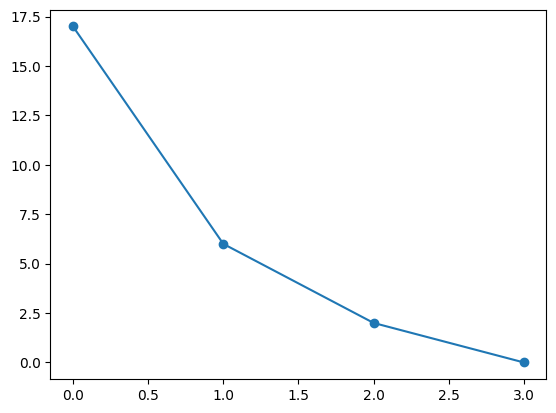

In [3]:
X, y = load_iris(return_X_y=True)
condition = y != 2
X, y = X[condition, 2:], y[condition]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
p = Perceptron(learning_rate=0.05, epochs=50)
p.fit(X_train, y_train)
plt.plot(p.error_, marker="o")

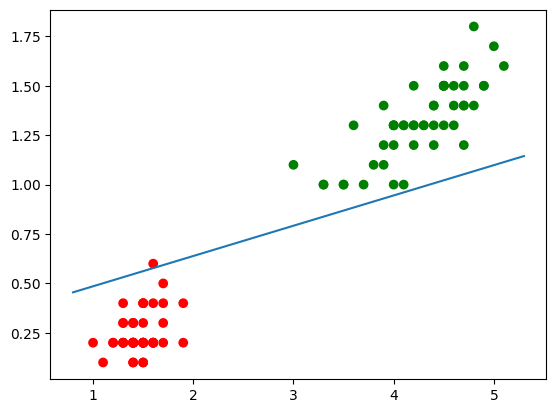

In [4]:
color = np.array(["red", "green"])
plt.scatter(X[:, 0], X[:, 1], c=color[y])
x1 = np.linspace(X[:, 0].min() - 0.2, X[:, 0].max() + 0.2, 100)
x2 = (-p.intercept_ - p.coef_[0] * x1) / p.coef_[1]
plt.plot(x1, x2)

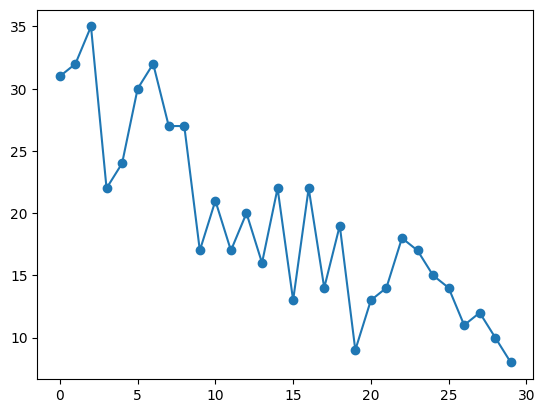

In [5]:
X, y = load_iris(return_X_y=True)
condition = y != 0
X, y = X[condition, 2:], y[condition]
y[y == 1] = 0
y[y == 2] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
p = Perceptron(learning_rate=0.05, epochs=30)
p.fit(X_train, y_train)
plt.plot(p.error_, marker="o")

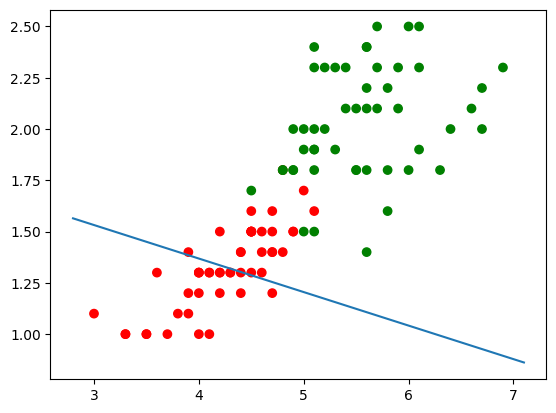

In [6]:
color = np.array(["red", "green"])
plt.scatter(X[:, 0], X[:, 1], c=color[y])
x1 = np.linspace(X[:, 0].min() - 0.2, X[:, 0].max() + 0.2, 100)
x2 = (-p.intercept_ - p.coef_[0] * x1) / p.coef_[1]
plt.plot(x1, x2)